# Tarea 1 - Deep Learning

El High Cadence Transient Survey (HiTS) observó el cielo durante 4 días cada 2 horas,
obteniendo una película del firmamento. El objetivo de HiTS fue encontrar objetos que
varían su brillo en corto tiempo, tales como supernovas, minutos después de su
explosión. Para esto, HiTS consideró una imagen de ciencia (imagen en el momento de
observación), y una imagen de template la cual fue restada de la imagen de ciencia,
produciendo así la imagen de diferencia. Esta última imagen de diferencia, se puede
escalar en función del ruido estimado por pixel produciendo la imagen de diferencia
razón-señal-a-ruido (SNR difference). En el caso de que un objeto aparezca
repentinamente en una observación, éste se debiese ver en la imagen de diferencia.
Muchas veces aparecen artefactos en las imágenes de diferencia debido a malas restas,
píxeles erróneos, o variación estadística de las imágenes.

El objetivo de esta tarea es clasificar estampillas de HiTS en artefactos y objetos reales.
Para esto, debe utilizar redes convolucionales. No existe limitación en el o los modelos a
implementar para resolver el problema. Se solicita que la predicción final sea entregada
con la siguiente identificación:
- Artefacto: 0
- Objeto real: 1

### Imports de librerías

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.preprocessing import RobustScaler
from torch.utils.data import Dataset, DataLoader
import pickle



In [680]:
if torch.cuda.is_available():
    print(f"CUDA disponible, usando {torch.cuda.get_device_name()}")
    device = torch.device("cuda")

else:
    print("CUDA no disponible, usando CPU")
    device = torch.device("cpu")

CUDA disponible, usando NVIDIA GeForce RTX 3050 Laptop GPU


## Carga y visualización del Dataset

### Carga del dataset con Pandas

In [681]:
data = pd.read_pickle("data_train.pkl")
print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['temp_images', 'SNR_images', 'diff_images', 'sci_images', 'labels', 'ID'])


### Distribución de clases

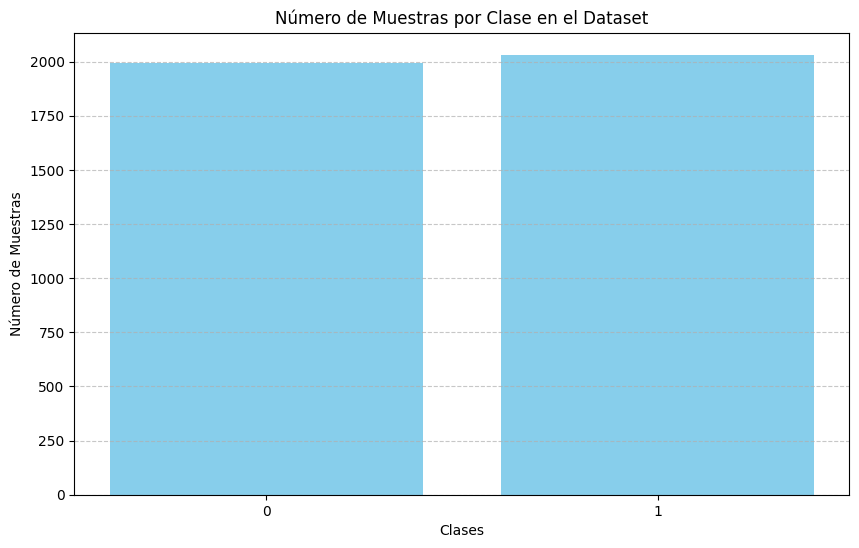

In [682]:
unique_labels, counts = np.unique(data["labels"], return_counts=True)

plt.figure(figsize=(10, 6))
plt.bar(unique_labels, counts, color='skyblue')
plt.xlabel('Clases')
plt.ylabel('Número de Muestras')
plt.title('Número de Muestras por Clase en el Dataset')
plt.xticks(unique_labels)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Definición de tensores del dataset

In [683]:
temp = torch.tensor(data['temp_images']).reshape(-1,21,21)
snr = torch.tensor(data['SNR_images']).reshape(-1,21,21)
diff = torch.tensor(data['diff_images']).reshape(-1,21,21)
sci = torch.tensor(data['sci_images']).reshape(-1,21,21)

### Visualización de diagrama de cajas

Notar la cantidad de offliers. La caja es indiferenciable.

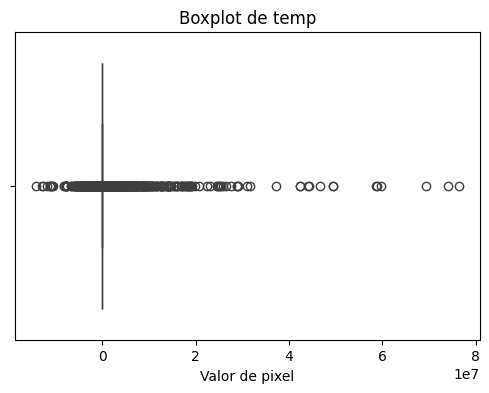

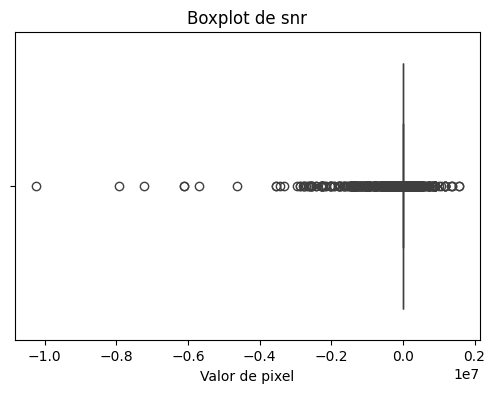

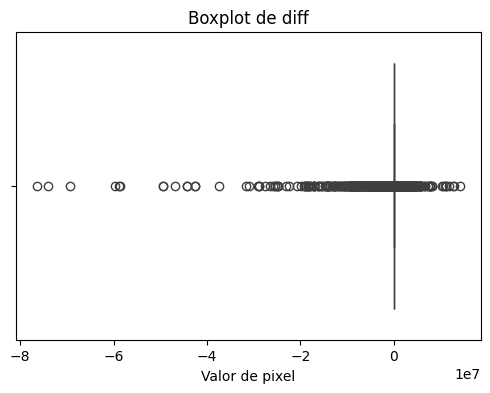

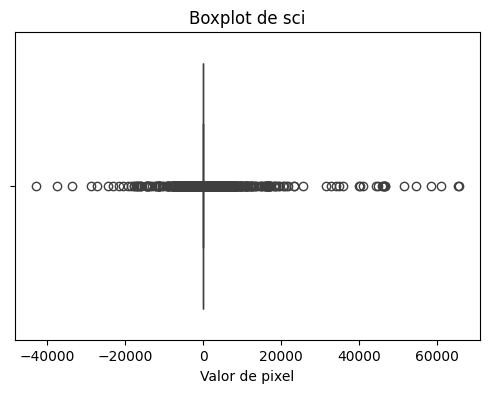

In [684]:
tensors = {
    'temp': temp,
    'snr': snr,
    'diff': diff,
    'sci': sci
}

for name, tensor in tensors.items():
    vals = tensor.view(-1).cpu().numpy()
    plt.figure(figsize=(6,4))
    sns.boxplot(x=vals)
    plt.title(f'Boxplot de {name}')
    plt.xlabel('Valor de pixel')
    plt.show()

## Split de training, test y validation

Se dividió el dataset en 80% de training, 10% de testing y 10% de validación.

In [685]:
X = torch.stack([
    temp,
    snr,
    diff,
    sci
], dim=1)
X_train, X_test, y_train, y_test = train_test_split(X, torch.tensor(data["labels"]), test_size=0.2, random_state=42, stratify=data["labels"])
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)



In [686]:
X_train.shape

torch.Size([3220, 4, 21, 21])

## Estandarización Robusta a outliers

Se utilizó RobustScaler de scikit-learn, el cual quita la media y escala los datos respecto de acuerdo a un rango interquantil, por defecto interquartil.

In [ ]:
n = X_train.shape[0]

scalers = []
for c in range(4):
    scaler = RobustScaler()
    ch_train = X_train[:, c].reshape(-1, 1).numpy()
    scaler.fit(ch_train)
    scalers.append(scaler)
    
    X_train[:, c] = torch.tensor(
        scaler.transform(ch_train).reshape(n, 21, 21), dtype=torch.float32)
    X_val[:, c] = torch.tensor(
        scaler.transform(X_val[:, c].reshape(-1, 1).numpy()).reshape(-1, 21, 21), dtype=torch.float32)
    X_test[:, c] = torch.tensor(
        scaler.transform(X_test[:, c].reshape(-1, 1).numpy()).reshape(-1, 21, 21), dtype=torch.float32)
    
with open('scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

## Data Augmentation

Se aplicaron rotaciones verticales, horizontales y ambos

In [688]:
def add_flip(images, labels):
    vflip = torch.flip(images, dims=[2])
    hflip = torch.flip(images, dims=[3])
    vhflip = torch.flip(vflip, dims=[3])

    augmented_images = torch.cat([images, vflip, hflip, vhflip])
    augmented_labels = labels.repeat(4)

    return augmented_images, augmented_labels

X_train, y_train = add_flip(X_train, y_train)

## Definición de modelo

El modelo desarrollado para la clasificación es una CNN de dos capas Conv2d con pooling y dos capas Fully Connected con 32 y 1 salida respectivamente. El modelo ocupa leaky relu con coeficiente 0.01, dropout con probabilidad de 50% y aplica la tecnica de rotation invariance, que permite a las capas convolucionales ver 4 rotaciones de la imagén que recibe, alimentado a la primera capa fully connected con la concatenación de las salida de la última capa convolucional, esto es un metodo de multiple vista de rotation invariance integrado directamente en el modelo, esto permite al modelo no perder información útil al simplemente hacer data augmentation (que si se hace en este caso con rotaciones en v y h) https://arxiv.org/abs/1904.00993 https://arxiv.org/pdf/1904.00993

In [ ]:
def convolution_resolution(size, kernel, stride, padding):
    if isinstance(kernel, tuple):
        kernel = kernel[0]
    if isinstance(stride, tuple):
        stride = stride[0]
    if isinstance(padding, tuple):
        padding = padding[0]
    return int((size + 2 * padding - kernel)/stride + 1)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)

        self.conv1 = nn.Conv2d(in_channels=4, out_channels=16, kernel_size=4, stride=1, padding=0)
        conv1_out_size = convolution_resolution(21, self.conv1.kernel_size, self.conv1.stride, self.conv1.padding)
        conv1_out_size = convolution_resolution(conv1_out_size, self.pool.kernel_size, self.pool.stride, 0)


        self.conv2 = nn.Conv2d(in_channels=self.conv1.out_channels, out_channels=32, kernel_size=3, stride=1, padding=0)
        conv2_out_size = convolution_resolution(conv1_out_size, self.conv2.kernel_size, self.conv2.stride, self.conv2.padding)
        conv2_out_size = convolution_resolution(conv2_out_size, self.pool.kernel_size, self.pool.stride, 0)

        self.fc1 = nn.Linear(self.conv2.out_channels*(conv2_out_size**2) * 4, 32) # * 4 por rotation invariance en 0, 90, 180 y 270
        self.fc2 = nn.Linear(32,1)


        self.relu = nn.LeakyReLU(negative_slope=0.01)
        self.dropout = nn.Dropout(p=0.5)
        self.flatten = nn.Flatten()

    def convolution_layers(self, x):
        x = self.dropout(self.pool(self.relu(self.conv1(x))))
        x = self.dropout(self.pool(self.relu(self.conv2(x))))

        return self.flatten(x)

    def forward(self, x):
        r0 = self.convolution_layers(x)
        r90 = self.convolution_layers(torch.rot90(x, k=1, dims=[2,3]))
        r180 = self.convolution_layers(torch.rot90(x, k=2, dims=[2,3]))
        r270 = self.convolution_layers(torch.rot90(x, k=3, dims=[2,3]))
        x = torch.cat([r0,r90,r180,r270], dim=1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

## Training loop

In [ ]:
# Pequeña modificación del training loop usado en las prácticas, solo se diferencia en que la perdida se calcula con la cantidad efectiva de imagenes y labels usados en vez de cantidad de batches.

def training_loop_cnn(model, loss_fn, optimizer, scheduler, train_loader, val_loader, epochs, patience):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    
    for epoch in range(epochs):
        # training
        model.train()
        current_train_loss = 0.0
        total = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            current_train_loss += loss.item() * images.size(0)
            total += labels.size(0)

        # Loss promedio por epoca
        current_train_loss /= total
        train_losses.append(current_train_loss)

        # Validacion
        model.eval()
        current_val_loss = 0.0
        total = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
                outputs = model(images)
                loss = loss_fn(outputs, labels)
                current_val_loss += loss.item() * images.size(0)
                total += labels.size(0)

        # Loss promedio por epoca
        current_val_loss /= total
        val_losses.append(current_val_loss)
        scheduler.step(current_val_loss)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {current_train_loss:.4f}, Val Loss: {current_val_loss:.4f}")

        # Early stopping logic
        if patience is not None:
            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                patience_counter = 0
                torch.save(model.state_dict(), "cnn_best_epoch.pth")
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs (no improvement for {patience} epochs).")
                break

    return train_losses, val_losses

## Separación en batches

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.clone().detach().float()

        self.y = y.clone().detach().long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_data = ImageDataset(X_train, y_train)
val_data = ImageDataset(X_val, y_val)
test_data = ImageDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

## Entrenamiento

In [692]:
cnn = CNN()
loss_fn =  nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=cnn.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                       mode='min',
                                                       patience=20,
                                                       factor=0.5,
                                                       min_lr=1e-6)

train_loss, val_loss = training_loop_cnn(model=cnn,
                                         loss_fn = loss_fn,
                                         optimizer = optimizer,
                                         scheduler = scheduler,
                                         train_loader= train_loader,
                                         val_loader = val_loader,
                                         epochs = 1000,
                                         patience = 999)




Epoch 1/1000, Train Loss: 7.4894, Val Loss: 0.4850
Epoch 2/1000, Train Loss: 0.7345, Val Loss: 0.4502
Epoch 3/1000, Train Loss: 0.5393, Val Loss: 0.4624
Epoch 4/1000, Train Loss: 4.0096, Val Loss: 0.4646
Epoch 5/1000, Train Loss: 0.5241, Val Loss: 0.3410
Epoch 6/1000, Train Loss: 0.4290, Val Loss: 0.2955
Epoch 7/1000, Train Loss: 0.3597, Val Loss: 0.2506
Epoch 8/1000, Train Loss: 0.3194, Val Loss: 0.2415
Epoch 9/1000, Train Loss: 0.2772, Val Loss: 0.2038
Epoch 10/1000, Train Loss: 0.4792, Val Loss: 0.1893
Epoch 11/1000, Train Loss: 0.3016, Val Loss: 0.1647
Epoch 12/1000, Train Loss: 0.2693, Val Loss: 0.1754
Epoch 13/1000, Train Loss: 1.3285, Val Loss: 0.1542
Epoch 14/1000, Train Loss: 0.1959, Val Loss: 0.1506
Epoch 15/1000, Train Loss: 0.1969, Val Loss: 0.1378
Epoch 16/1000, Train Loss: 2.1170, Val Loss: 0.2320
Epoch 17/1000, Train Loss: 0.2708, Val Loss: 0.1419
Epoch 18/1000, Train Loss: 0.1961, Val Loss: 0.1263
Epoch 19/1000, Train Loss: 0.2188, Val Loss: 0.1292
Epoch 20/1000, Train 

## Resultados de Entrenamiento

Observar que la mejor epoca es la 72 y es la que el modelo efectivamente va a ocupar.
Epoch 72/1000, Train Loss: 0.0603, Val Loss: 0.0571

Además se puede apreciar en el gráfico que aún existen outliers que afectaron al modelo.

Text(0.5, 1.0, 'Loss')

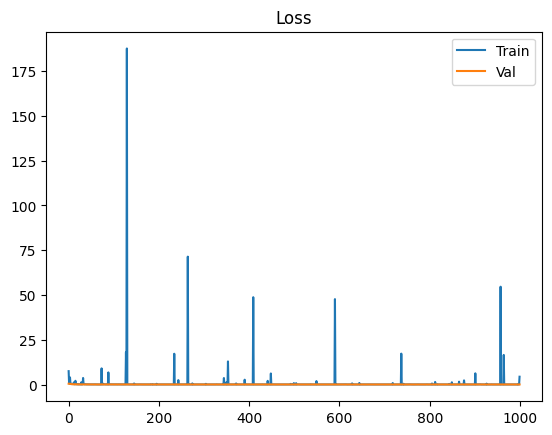

In [ ]:
plt.plot(train_loss, label="Train")
plt.plot(val_loss, label="Val")
plt.legend()
plt.title("Loss")

In [ ]:
import numpy as np

y_true, y_pred = [], []

cnn.load_state_dict(torch.load("cnn_best_epoch.pth", map_location=device))
cnn.to(device)
cnn.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = cnn(images)              
        probs = torch.sigmoid(outputs)    

        predicted = (probs > 0.5).long()   

        y_true.extend(labels.cpu().numpy().astype(int).flatten())
        y_pred.extend(predicted.cpu().numpy().flatten())

print("\nReporte de clasificación (CNN):")
print(classification_report(
    np.array(y_true),
    np.array(y_pred),
    digits=4
))


Reporte de clasificación (CNN):
              precision    recall  f1-score   support

           0     0.9949    0.9749    0.9848       199
           1     0.9760    0.9951    0.9854       204

    accuracy                         0.9851       403
   macro avg     0.9854    0.9850    0.9851       403
weighted avg     0.9853    0.9851    0.9851       403



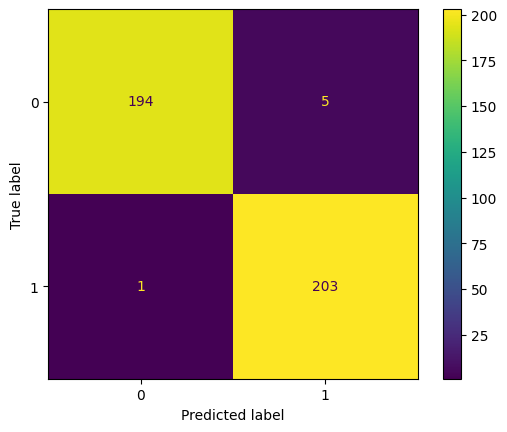

[[194   5]
 [  1 203]]


In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_plot.plot()
plt.show()

print(cm)

In [ ]:
cnn = CNN()

unlab = pd.read_pickle("unlab_test.pkl")
temp2 = torch.tensor(unlab['temp_images']).reshape(-1,21,21)
snr2 = torch.tensor(unlab['SNR_images']).reshape(-1,21,21)
diff2 = torch.tensor(unlab['diff_images']).reshape(-1,21,21)
sci2 = torch.tensor(unlab['sci_images']).reshape(-1,21,21)
X2 = torch.stack([temp2, snr2, diff2, sci2], dim=1).float()

with open('scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)

for c in range(4):
    X2[:, c] = torch.tensor(
        scalers[c].transform(X2[:, c].reshape(-1, 1).numpy()).reshape(-1, 21, 21),
        dtype=torch.float32)

cnn.load_state_dict(torch.load("cnn_best_epoch.pth", map_location=device))
cnn.to(device)
cnn.eval()

y_pred = []
with torch.no_grad():
    X2 = X2.to(device)
    outputs = cnn(X2)
    probs = torch.sigmoid(outputs)
    predicted = (probs > 0.5).long()
    y_pred.extend(predicted.cpu().numpy().flatten())

preds = pd.DataFrame({
    'ID': unlab['ID'],
    'predicted': y_pred
})

preds.to_csv("predicted.csv", index=False)